# AI Financial Alert Risk Scoring — reproducible solution

Predicts the probability that each hidden-test alert is **escalated** (metric: ROC-AUC).
This notebook reproduces the full pipeline **from the raw competition files to the submission** in one pass.

| | |
|---|---|
| Final model | equal-weight rank ensemble of 5 models (CatBoost ×2, LightGBM, hybrid linear+boosting, logistic regression) |
| Validation | StratifiedKFold(5) × 3 seeds, early stopping on a separate 20 % slice of each training fold |
| CV ROC-AUC | **0.65334** (3-seed bag); single seed 0.6520 ± 0.0014 (5 seeds) |
| Runtime | ~7 min on 2 CPU cores (`FAST_MODE=True`: ~2.5 min, 1 seed, slightly different numbers) |
| EDA website | see the submission form (Streamlit app) |

**How to run.** Put the five competition files in `data/` (or the project root — found automatically), set `TEAM_ID`, then *Run All*.
The output is `submissions/team_<TEAM_ID>.csv`. Package versions used are printed in the first cell and pinned in `requirements.txt`.

In [1]:
import glob, json, sys, time, warnings
from pathlib import Path
import numpy as np, pandas as pd
import lightgbm as lgb, catboost, sklearn, scipy, pyarrow
warnings.filterwarnings("ignore")

TEAM_ID   = "3B832E89"                 # official team ID
# folder with the 5 competition files: first of these that contains train_signals.csv
DATA_DIR  = next(p for p in [Path("../data"), Path(".."), Path("data"), Path(".")] if (p / "train_signals.csv").exists())
OUT_DIR   = Path("../submissions")
FAST_MODE = False                      # True: 1 seed for a quick check (numbers differ slightly)
SEEDS     = (42,) if FAST_MODE else (42, 202, 777)

# column names
ID, DATE, TARGET, SUB_PRED = "signal_id", "signal_sanasi", "eskalatsiya", "ehtimollik"
DATA = DATA_DIR

# LightGBM parameters (tuned once with Optuna on honest CV; frozen)
LGB_PARAMS = {
 "learning_rate": 0.013399549522183024,
 "num_leaves": 8,
 "min_child_samples": 142,
 "feature_fraction": 0.5673295021425665,
 "bagging_fraction": 0.7159725093210578,
 "lambda_l1": 0.017888967192999938,
 "lambda_l2": 2.801635158716261
}

print("data:", DATA_DIR)
print("python", sys.version.split()[0])
for m in [pd, np, sklearn, lgb, catboost, scipy, pyarrow]:
    print(f"{m.__name__:12s} {m.__version__}")
T0 = time.time()
def log(msg): print(f"[{time.time()-T0:6.0f}s] {msg}", flush=True)

data: ../data
python 3.11.15
pandas       3.0.2
numpy        2.4.4
sklearn      1.8.0
lightgbm     4.7.0
catboost     1.2.10
scipy        1.17.1
pyarrow      25.0.1


## 1. Data loading and integrity checks

The data are relational: one alert ↔ many transactions (median ~460 over 180 days).
`miqdor_indeksi` is cast to float32 to save memory (the final model was trained this way; it only affects exact
equality of amounts, which no feature uses).

**Leakage rule:** only information available at the alert moment may be used. Each alert's history is a 180-day
window that ends with a ~3-minute burst of transactions right before the alert. `signal_sanasi` is a date **without
time**: for 99 % of alerts the burst ends just before 00:00 of that date, while for 21 train / 2 test alerts the whole
window is shifted by one day and the burst ends just before 24:00 of the same date (840 / 51 transactions later than
00:00). Those transactions are the same pre-alert burst, not post-alert data, so **all transactions are used**
(removing them would delete these alerts' burst and shorten their window). The check below verifies this.

In [2]:
# ---- verbatim copy of src/data.py ----
"""Загрузка данных с ужатыми типами (важно: на машине пользователя всего 3 ГБ RAM)."""
import numpy as np
import pandas as pd


def load_signals(split: str) -> pd.DataFrame:
    df = pd.read_csv(DATA / f"{split}_signals.csv", parse_dates=[DATE])
    return df


def load_transactions(split: str) -> pd.DataFrame:
    df = pd.read_parquet(DATA / f"{split}_transactions.parquet")
    df["kirim_chiqim"] = df["kirim_chiqim"].astype("category")
    df["tranzaksiya_turi"] = df["tranzaksiya_turi"].astype("category")
    df["miqdor_indeksi"] = df["miqdor_indeksi"].astype(np.float32)
    return df


def load_sample_submission() -> pd.DataFrame:
    f = sorted(glob.glob(str(DATA / "sample_submission*.csv")))[0]   # tolerate "sample_submission (3).csv"
    return pd.read_csv(f)


In [3]:
sig_tr, sig_te = load_signals("train"), load_signals("test")
sub_tpl = load_sample_submission()
print(f"train alerts {len(sig_tr):,}   test alerts {len(sig_te):,}   escalation rate {sig_tr[TARGET].mean():.4f}")

# --- integrity checks (fail loudly if anything is off)
assert sig_tr[ID].is_unique and sig_te[ID].is_unique
assert not set(sig_tr[ID]) & set(sig_te[ID]), "train/test alert IDs overlap"
assert (sub_tpl[ID].values == sig_te[ID].values).all(), "sample_submission order != test_signals order"
for split, sig in [("train", sig_tr), ("test", sig_te)]:
    raw = load_transactions(split)
    sb = (raw[ID].map(sig.set_index(ID)[DATE]) - raw["tranzaksiya_vaqti"]).dt.total_seconds()
    later = raw.loc[sb < 0, ID].unique()
    span = sb.groupby(raw[ID]).agg(lambda v: v.max() - v.min()) / 86400
    r64 = pd.read_parquet(DATA / f"{split}_transactions.parquet", columns=[ID, "tranzaksiya_vaqti", "miqdor_indeksi"])  # float64: float32 creates false ties
    dup = r64.duplicated(["tranzaksiya_vaqti", "miqdor_indeksi"], keep=False)
    shared = r64.loc[dup].groupby(["tranzaksiya_vaqti", "miqdor_indeksi"])[ID].nunique().gt(1).sum()
    del r64
    print(f"{split}: {len(raw):,} tx | later than 00:00 of signal date: {(sb < 0).sum()} tx in {len(later)} alerts, "
          f"all within that date: {(sb >= -86400).all()} | max history span {span.max():.3f} days "
          f"| every alert has history: {raw[ID].nunique() == len(sig)} | tx shared between alerts: {shared}")
    assert (sb >= -86400).all() and span.max() <= 180.0 + 1e-6 and raw[ID].nunique() == len(sig) and shared == 0
    del raw

train alerts 14,000   test alerts 6,000   escalation rate 0.1718


train: 6,987,663 tx | later than 00:00 of signal date: 840 tx in 21 alerts, all within that date: True | max history span 180.000 days | every alert has history: True | tx shared between alerts: 0


test: 3,027,575 tx | later than 00:00 of signal date: 51 tx in 2 alerts, all within that date: True | max history span 180.000 days | every alert has history: True | tx shared between alerts: 0


## 2. EDA highlights that shaped the model

The full EDA is on the team website. Three findings drove the modelling decisions:

1. **Each instrument has its own 'normal' amount** (card-in ≈ −0.5, international ≈ +2) → never average instruments
   together; compute statistics per *instrument × direction* (largest gain, +0.039 AUC).
2. **A common customer scale hides the signal.** Mean amounts are strongly correlated across instruments; the
   predictive part is a small contrast: *cash deposits and card spending large relative to bank transfers*.
3. **Time carries no signal** (uniform timestamps, random instrument order, identical trend in both classes);
   the ~3-minute burst before each alert is real but uninformative.

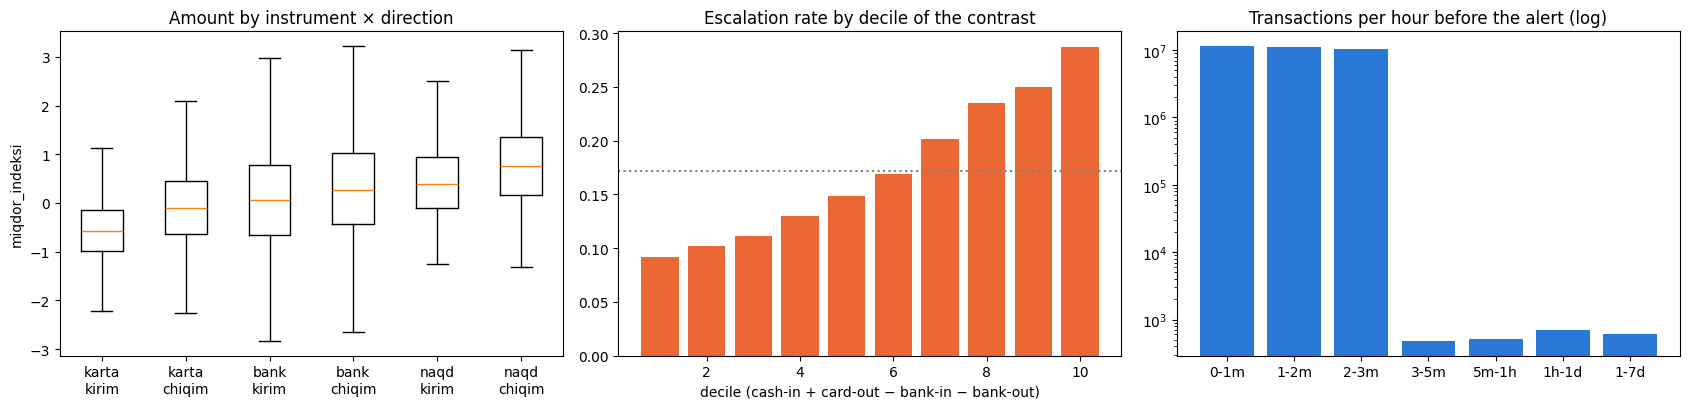

Single hand-written contrast (no training): ROC-AUC = 0.6292


In [4]:
import matplotlib.pyplot as plt
tx = load_transactions("train")
cr = tx["tranzaksiya_turi"].astype(str) + "_" + tx["kirim_chiqim"].astype(str)
means = tx.groupby([tx[ID], cr], observed=True)["miqdor_indeksi"].mean().unstack()
y_all = sig_tr.set_index(ID)[TARGET].reindex(means.index)
contrast = means["naqd_kirim"] + means["karta_chiqim"] - means["bank_otkazmasi_kirim"] - means["bank_otkazmasi_chiqim"]
sb = (tx[ID].map(sig_tr.set_index(ID)[DATE]) - tx["tranzaksiya_vaqti"]).dt.total_seconds()

fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
order = ["karta_kirim", "karta_chiqim", "bank_otkazmasi_kirim", "bank_otkazmasi_chiqim", "naqd_kirim", "naqd_chiqim"]
ax[0].boxplot([tx.loc[cr == c, "miqdor_indeksi"].sample(20000, random_state=0) for c in order], showfliers=False)
ax[0].set_xticks(range(1, 7), [c.replace("bank_otkazmasi", "bank").replace("_", "\n") for c in order])
ax[0].set_title("Amount by instrument × direction"); ax[0].set_ylabel("miqdor_indeksi")
m = contrast.notna(); q = pd.qcut(contrast[m].rank(method="first"), 10, labels=False)
ax[1].bar(range(1, 11), y_all[m].groupby(q).mean().values, color="#eb6834")
ax[1].axhline(y_all.mean(), ls=":", c="gray"); ax[1].set_title("Escalation rate by decile of the contrast")
ax[1].set_xlabel("decile (cash-in + card-out − bank-in − bank-out)")
bins = [0, 60, 120, 180, 300, 3600, 86400, 7 * 86400]
cnt = pd.cut(sb, bins, include_lowest=True).value_counts().sort_index()
ax[2].bar(["0-1m", "1-2m", "2-3m", "3-5m", "5m-1h", "1h-1d", "1-7d"], cnt.values / (np.diff(bins) / 3600), color="#2a78d6")
ax[2].set_yscale("log"); ax[2].set_title("Transactions per hour before the alert (log)")
plt.tight_layout(); plt.show()
from sklearn.metrics import roc_auc_score
print(f"Single hand-written contrast (no training): ROC-AUC = {roc_auc_score(y_all[m], contrast[m]):.4f}")
del tx, cr, sb

## 3. Features (one row per alert, computed only from that alert's own pre-alert history)

| group | # | description |
|---|---|---|
| base aggregates | 59 | amount stats (all / incoming / outgoing), type shares & counts, balance, activity, alert date |
| distribution shape | 49 | kurtosis, Bowley skew, inter-quantile ranges, tail ratios |
| instrument × direction | 130 | count / mean / std / quantiles for each of 8 combinations — **the key EDA insight** |
| explicit contrast | 13 | cash-in + card-out − bank-in − bank-out at several statistics |
| linear-model inputs | 76 | instrument levels + customer-scale / skew decomposition + log counts |

No global statistics use the target. Instrument norms and missing-value medians are computed on **train only**
and applied unchanged to test.

In [5]:
# ---- verbatim copy of src/features.py ----
"""Агрегация транзакций (уровень транзакции) -> признаки (уровень алерта).

Baseline-набор. Все признаки считаются ТОЛЬКО внутри одного signal_id,
никаких глобальных статистик по датасету -> лика между train/test нет.
"""
import numpy as np
import pandas as pd


TURLAR = ["karta", "bank_otkazmasi", "naqd", "xalqaro"]


def _amount_stats(g, prefix):
    """Статистики miqdor_indeksi по сгруппированному объекту."""
    out = g["miqdor_indeksi"].agg(
        ["count", "mean", "std", "min", "max", "median", "sum", "skew"]
    )
    out.columns = [f"{prefix}_{c}" for c in out.columns]
    q = g["miqdor_indeksi"].quantile([0.10, 0.25, 0.75, 0.90, 0.99]).unstack()
    q.columns = [f"{prefix}_q{int(c * 100):02d}" for c in q.columns]
    return out.join(q)


def build_features(tx: pd.DataFrame, signals: pd.DataFrame) -> pd.DataFrame:
    tx = tx.copy()
    tx["is_out"] = (tx["kirim_chiqim"].astype(str) == "chiqim").astype(np.int8)
    for t in TURLAR:
        tx[f"is_{t}"] = (tx["tranzaksiya_turi"].astype(str) == t).astype(np.int8)
    tx["day"] = tx["tranzaksiya_vaqti"].values.astype("datetime64[D]")

    g = tx.groupby(ID, observed=True)

    # --- общие статистики сумм
    feats = _amount_stats(g, "amt")

    # --- доли по направлению и типу
    ratios = g[["is_out"] + [f"is_{t}" for t in TURLAR]].mean()
    ratios.columns = [f"r_{c[3:]}" for c in ratios.columns]
    feats = feats.join(ratios)

    # сырые счётчики типов (для xalqaro сырое количество работало лучше доли)
    counts = g[[f"is_{t}" for t in TURLAR]].sum()
    counts.columns = [f"n_{c[3:]}" for c in counts.columns]
    feats = feats.join(counts)

    # --- статистики отдельно по приходу и расходу
    for flag, prefix in [(0, "in"), (1, "out")]:
        sub = tx[tx["is_out"] == flag]
        s = _amount_stats(sub.groupby(ID, observed=True), prefix)
        feats = feats.join(s)

    feats["bal_sum"] = feats["in_sum"].fillna(0) - feats["out_sum"].fillna(0)
    feats["bal_ratio"] = feats["in_sum"].fillna(0) / (feats["out_sum"].abs().fillna(0) + 1e-6)
    feats["out_in_cnt_ratio"] = feats["out_count"].fillna(0) / (feats["in_count"].fillna(0) + 1e-6)

    # --- активность во времени
    act = g.agg(
        n_days=("day", "nunique"),
        t_min=("tranzaksiya_vaqti", "min"),
        t_max=("tranzaksiya_vaqti", "max"),
    )
    act["span_days"] = (act["t_max"] - act["t_min"]).dt.total_seconds() / 86400
    act["tx_per_day"] = feats["amt_count"] / act["n_days"].clip(lower=1)
    act["density"] = act["n_days"] / act["span_days"].clip(lower=1)
    feats = feats.join(act[["n_days", "span_days", "tx_per_day", "density"]])

    # --- признаки самого алерта
    s = signals.set_index(ID)
    feats = feats.join(s[[DATE]])
    feats["sig_month"] = feats[DATE].dt.month
    feats["sig_dow"] = feats[DATE].dt.dayofweek
    feats["sig_doy"] = feats[DATE].dt.dayofyear
    feats["sig_days_since_start"] = (feats[DATE] - pd.Timestamp("2025-01-01")).dt.days
    feats = feats.drop(columns=[DATE])

    # порядок строк = порядок в signals
    feats = feats.reindex(s.index)
    return feats.astype(np.float32)


In [6]:
# ---- verbatim copy of src/features_v3.py ----
"""Признаки формы распределения сумм.

Мотивация (проверено вручную на train):
  - out_skew даёт чистую монотонную зависимость: 0.209 -> 0.111 по децилям.
    Асимметрия НЕ зависит от числа наблюдений -> признак честный.
  - amt_min сильно коррелирует с n_tx (-0.346): минимум это порядковая
    статистика, она механически падает с ростом N. Признак мутный, чиним.

Всё считается внутри одного signal_id. Глобальных статистик нет -> лика нет.
"""
import numpy as np
import pandas as pd

QS = [0.01, 0.02, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.98, 0.99]


def _shape_block(g, prefix):
    """Характеристики формы, инвариантные к числу наблюдений."""
    q = g["miqdor_indeksi"].quantile(QS).unstack()
    q.columns = [f"q{int(c*100):02d}" for c in q.columns]

    f = pd.DataFrame(index=q.index)
    f[f"{prefix}_kurt"] = g["miqdor_indeksi"].apply(pd.Series.kurt)

    # размахи
    iqr = q["q75"] - q["q25"]
    f[f"{prefix}_iqr"] = iqr
    f[f"{prefix}_idr"] = q["q90"] - q["q10"]          # inter-decile range
    f[f"{prefix}_range99"] = q["q99"] - q["q01"]

    # асимметрия Боули: робастная версия skew, устойчива к выбросам
    f[f"{prefix}_bowley"] = (q["q75"] + q["q25"] - 2 * q["q50"]) / (iqr + 1e-6)
    # хвостовая асимметрия по децилям
    f[f"{prefix}_tail_asym"] = (q["q90"] + q["q10"] - 2 * q["q50"]) / (q["q90"] - q["q10"] + 1e-6)
    # квантильный эксцесс: насколько тяжёлые хвосты относительно середины
    f[f"{prefix}_qkurt"] = (q["q90"] - q["q10"]) / (iqr + 1e-6)
    f[f"{prefix}_qkurt99"] = (q["q99"] - q["q01"]) / (iqr + 1e-6)
    # какой хвост длиннее: левый или правый
    f[f"{prefix}_tail_ratio"] = (q["q50"] - q["q01"]) / (q["q99"] - q["q50"] + 1e-6)
    f[f"{prefix}_tail_ratio_d"] = (q["q50"] - q["q10"]) / (q["q90"] - q["q50"] + 1e-6)
    # коэффициент вариации через робастные оценки
    f[f"{prefix}_rcv"] = iqr / (q["q50"].abs() + 1e-6)

    # низкие квантили — спокойная замена минимуму (устойчивы к N)
    for c in ["q01", "q02", "q05"]:
        f[f"{prefix}_{c}"] = q[c]
    # насколько сам минимум оторван от остального хвоста
    f[f"{prefix}_min_gap"] = q["q01"] - g["miqdor_indeksi"].min()

    return f


def build_features_v3(tx: pd.DataFrame, signals: pd.DataFrame) -> pd.DataFrame:
    tx = tx.copy()
    tx["is_out"] = (tx["kirim_chiqim"].astype(str) == "chiqim").astype(np.int8)
    idx = signals[ID]

    out = _shape_block(tx.groupby(ID, observed=True), "sh_amt")
    # расходы информативнее прихода -> считаем отдельно
    for flag, prefix in [(1, "sh_out"), (0, "sh_in")]:
        sub = tx[tx["is_out"] == flag]
        out = out.join(_shape_block(sub.groupby(ID, observed=True), prefix))

    # модуль суммы: отдельная характеристика "размаха" безотносительно знака
    tx["abs_amt"] = tx["miqdor_indeksi"].abs()
    ga = tx.groupby(ID, observed=True)["abs_amt"]
    out["abs_mean"] = ga.mean()
    out["abs_std"] = ga.std()
    out["abs_max"] = ga.max()
    out["abs_skew"] = ga.skew()

    return out.reindex(idx).astype(np.float32)


In [7]:
# ---- verbatim copy of src/features_v4.py ----
"""Суммы в разрезе ТИП x НАПРАВЛЕНИЕ + гистограмма распределения сумм.

Мотивация (проверено вручную по децилям на train):
  mean bank_otkazmasi_chiqim: 0.230 -> 0.113  (размах 0.117)
  mean xalqaro_chiqim:        0.237 -> 0.144  (размах 0.093)
  mean bank_otkazmasi_kirim:  0.220 -> 0.126  (размах 0.094)
  для сравнения out_skew:     0.209 -> 0.111  (размах 0.098)

То есть средняя сумма банковского перевода сильнее прежнего чемпиона.
Статистики сумм В РАЗРЕЗЕ ТИПА модель раньше не видела вообще: были только
доли типов и статистики сумм по направлению, но не их пересечение.

Границы гистограммы фиксированные (заданы константой), а не посчитанные
по данным -> одинаковы для train и test, лика нет.
"""
import numpy as np
import pandas as pd

CROSSES = [
    "karta_kirim", "karta_chiqim",
    "bank_otkazmasi_kirim", "bank_otkazmasi_chiqim",
    "naqd_kirim", "naqd_chiqim",
    "xalqaro_kirim", "xalqaro_chiqim",
]

# фиксированные границы: miqdor_indeksi стандартизован организаторами,
# диапазон -2.91 .. 6.69 на train
BINS = np.array([-np.inf, -2.5, -2.0, -1.6, -1.2, -0.9, -0.6, -0.35, -0.1,
                 0.15, 0.4, 0.7, 1.0, 1.4, 1.8, 2.3, 3.0, 4.0, np.inf])


def build_features_v4(tx: pd.DataFrame, signals: pd.DataFrame) -> pd.DataFrame:
    tx = tx.copy()
    tx["cross"] = (tx["tranzaksiya_turi"].astype(str) + "_"
                   + tx["kirim_chiqim"].astype(str))
    idx = signals[ID]
    out = pd.DataFrame(index=pd.Index(idx, name=ID))

    # --- статистики сумм по каждой из 8 комбинаций
    for c in CROSSES:
        sub = tx[tx["cross"] == c]
        if len(sub) == 0:
            continue
        g = sub.groupby(ID, observed=True)["miqdor_indeksi"]
        f = g.agg(["count", "mean", "std", "median", "max", "min", "sum", "skew"])
        f.columns = [f"x_{c}_{k}" for k in f.columns]
        q = g.quantile([0.25, 0.75, 0.90]).unstack()
        q.columns = [f"x_{c}_q{int(v*100):02d}" for v in q.columns]
        out = out.join(f.join(q))

    # --- отношения средних между инструментами:
    # "перевод в среднем во сколько раз крупнее карточной операции"
    def ratio(a, b, name):
        ca, cb = f"x_{a}_mean", f"x_{b}_mean"
        if ca in out.columns and cb in out.columns:
            out[name] = out[ca] / (out[cb].abs() + 1e-6)

    ratio("bank_otkazmasi_chiqim", "karta_chiqim", "x_bank_vs_karta_out")
    ratio("bank_otkazmasi_kirim", "karta_kirim", "x_bank_vs_karta_in")
    ratio("naqd_chiqim", "karta_chiqim", "x_naqd_vs_karta_out")
    ratio("xalqaro_chiqim", "karta_chiqim", "x_xalqaro_vs_karta_out")
    ratio("bank_otkazmasi_chiqim", "bank_otkazmasi_kirim", "x_bank_out_vs_in")
    ratio("naqd_chiqim", "naqd_kirim", "x_naqd_out_vs_in")

    # --- гистограмма сумм: доля транзакций в каждой корзине.
    # Моменты (mean/skew/kurt) сжимают форму с потерями; гистограмма
    # показывает её как есть, включая горбы и провалы.
    codes = np.digitize(tx["miqdor_indeksi"].values, BINS[1:-1])
    h = pd.crosstab(tx[ID].values, codes, normalize="index")
    h.columns = [f"hist_{int(c):02d}" for c in h.columns]
    out = out.join(h.reindex(idx))

    # --- гистограмма отдельно по расходам (расходы информативнее)
    sub = tx[tx["kirim_chiqim"].astype(str) == "chiqim"]
    codes = np.digitize(sub["miqdor_indeksi"].values, BINS[1:-1])
    ho = pd.crosstab(sub[ID].values, codes, normalize="index")
    ho.columns = [f"histout_{int(c):02d}" for c in ho.columns]
    out = out.join(ho.reindex(idx))

    return out.astype(np.float32)


In [8]:
# ---- verbatim copy of src/features_v7.py ----
"""Разности расположения сумм между инструментами + разложение на
«масштаб клиента» и «перекос по инструментам».

Наблюдение: miqdor_indeksi ведёт себя как стандартизованный логарифм суммы
(у каждого инструмента свой сдвиг: karta_kirim ~ -0.54, xalqaro ~ +2.17).
В лог-шкале РАЗНОСТЬ = логарифм отношения реальных сумм. Проверка по децилям:
  mean(bank_kirim) - mean(naqd_kirim): 0.281 -> 0.104, размах 0.177
  прежний топ (отношение bank/karta):   размах 0.132
Отношения на стандартизованной шкале плохо ведут себя около нуля, разности нет.

Разложение: сумма ~ масштаб клиента + норма инструмента + перекос.
Норма инструмента = средняя по train-транзакциям (константа, таргет не нужен),
считается один раз по обучающим данным и применяется к тесту без изменений.
"""
import itertools
import numpy as np
import pandas as pd

STATS = ["mean", "median", "q25", "q75"]


def type_norms(tx_train: pd.DataFrame) -> dict:
    """Нормы инструментов по ОБУЧАЮЩИМ транзакциям. Таргет не используется."""
    c = tx_train["tranzaksiya_turi"].astype(str) + "_" + tx_train["kirim_chiqim"].astype(str)
    g = tx_train["miqdor_indeksi"].astype(np.float64).groupby(c)
    return {"mean": g.mean().to_dict(), "median": g.median().to_dict()}


def build_features_v7(X4: pd.DataFrame, norms: dict) -> pd.DataFrame:
    """На вход — признаки v4 (статистики по 8 комбинациям), на выход — разности."""
    cols = {}

    # --- все попарные разности расположения
    for st in STATS:
        for a, b in itertools.combinations(CROSSES, 2):
            ca, cb = f"x_{a}_{st}", f"x_{b}_{st}"
            if ca in X4 and cb in X4:
                cols[f"d_{st}_{a}__{b}"] = X4[ca] - X4[cb]

    # --- разложение: отклонение от нормы инструмента
    for st in ["mean", "median"]:
        dev = pd.DataFrame({c: X4[f"x_{c}_{st}"] - norms[st][c]
                            for c in CROSSES if f"x_{c}_{st}" in X4})
        w = pd.DataFrame({c: X4[f"x_{c}_count"].fillna(0) for c in dev.columns})
        # масштаб клиента: взвешенное среднее отклонений по всем инструментам
        scale = (dev.fillna(0) * w).sum(axis=1) / w.sum(axis=1).clip(lower=1)
        cols[f"scale_{st}"] = scale
        # перекос: насколько каждый инструмент отличается от общего масштаба клиента
        for c in dev.columns:
            cols[f"skewto_{st}_{c}"] = dev[c] - scale
        cols[f"skewto_{st}_spread"] = dev.sub(scale, axis=0).std(axis=1)

    return pd.DataFrame(cols, index=X4.index).astype(np.float32)


In [9]:
# ---- verbatim copy of src/features_v8.py ----
"""Явный контраст, найденный разведкой.

Средние по 8 инструментам сильно коррелированы (0.5–0.88): есть общий
«масштаб клиента» (PC1, 62% дисперсии), но он почти не предсказывает (AUC 0.535).
Сигнал — в малом контрасте (PC5, 4% дисперсии, AUC 0.617):
    + naqd_kirim + karta_chiqim  − bank_otkazmasi_kirim − bank_otkazmasi_chiqim
Деревья делят по отдельным средним, где доминирует бесполезный масштаб, и
контраст ловят плохо. Даю его явно. Веса ФИКСИРОВАНЫ (±1), по данным не
подгоняются -> лика нет.
"""
import numpy as np
import pandas as pd

POS = ["naqd_kirim", "karta_chiqim"]
NEG = ["bank_otkazmasi_kirim", "bank_otkazmasi_chiqim"]


def build_features_v8(X4: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=X4.index)
    for st in ["mean", "median", "q25", "q75"]:
        p = sum(X4[f"x_{c}_{st}"] for c in POS)
        n = sum(X4[f"x_{c}_{st}"] for c in NEG)
        out[f"ctr_{st}"] = p - n
        # две половины контраста отдельно
        out[f"ctr_{st}_cash_vs_bank_in"] = X4[f"x_naqd_kirim_{st}"] - X4[f"x_bank_otkazmasi_kirim_{st}"]
        out[f"ctr_{st}_card_vs_bank_out"] = X4[f"x_karta_chiqim_{st}"] - X4[f"x_bank_otkazmasi_chiqim_{st}"]
    # версия, устойчивая к пропуску наличных: только карта vs банк
    out["ctr_mean_nocash"] = (X4["x_karta_chiqim_mean"] + X4["x_karta_kirim_mean"]
                              - X4["x_bank_otkazmasi_kirim_mean"] - X4["x_bank_otkazmasi_chiqim_mean"])
    return out.astype(np.float32)


In [10]:
def features(split, norms=None):
    sig = load_signals(split); tx = load_transactions(split)
    if norms is None:
        norms = type_norms(tx)                  # instrument norms - TRAIN only
    X1 = build_features(tx, sig)
    X3 = build_features_v3(tx, sig)
    X4 = build_features_v4(tx, sig)
    del tx
    X7 = build_features_v7(X4, norms)
    X8 = build_features_v8(X4)
    tree = pd.concat([X1, X3, X4, X8], axis=1)
    lin_cols = [f"x_{c}_{s}" for c in CROSSES for s in ["mean", "median", "q25", "q75", "q90", "min"]]
    dec = [c for c in X7.columns if not c.startswith("d_")]
    cnt = np.log1p(X4[[f"x_{c}_count" for c in CROSSES]].fillna(0)).add_suffix("_log")
    lin = pd.concat([X4[lin_cols], X7[dec], cnt], axis=1)
    return sig, tree, lin, norms

sig_tr, Xtr, Ltr, norms = features("train")
sig_te, Xte, Lte, _ = features("test", norms)
Xte = Xte[Xtr.columns]; Lte = Lte[Ltr.columns]
y = sig_tr.set_index(ID)[TARGET].reindex(Xtr.index)

assert (Xtr.index.values == sig_tr[ID].values).all() and (Xte.index.values == sig_te[ID].values).all()
assert y.notna().all() and TARGET not in Xtr.columns and TARGET not in Ltr.columns
assert list(Xtr.columns) == list(Xte.columns) and list(Ltr.columns) == list(Lte.columns)

lin_med = Ltr.median()                          # train-only statistics for the linear model
def lin_prep(L):
    na = pd.DataFrame({c + "_na": L[c].isna().astype(float) for c in Ltr.columns if Ltr[c].isna().any()}, index=L.index)
    return pd.concat([L.fillna(lin_med), na], axis=1)
Ztr, Zte = lin_prep(Ltr), lin_prep(Lte)
log(f"features: trees {Xtr.shape[1]}, linear {Ltr.shape[1]}; train {len(Xtr)}, test {len(Xte)}")

[    59s] features: trees 251, linear 76; train 14000, test 6000


## 4. Models and validation

* **Validation:** train/test are split at random (identical date ranges, interleaved IDs) and every alert is a separate
  customer (no shared transactions), so `StratifiedKFold(5)` is appropriate. A single split varied by ±0.015 AUC, so
  every result is averaged over 3 seeds.
* **Honest early stopping:** inside each training fold 20 % is held out *only* for early stopping; the validation fold
  never influences training (using it inflated AUC by +0.005).
* **Models:** the main signal is almost linear in instrument levels, while trees approximate it as a staircase — hence a
  logistic regression and a **hybrid** (LightGBM boosted from the logistic-regression score) next to CatBoost/LightGBM.

In [11]:
# ---- verbatim copy of src/hybrid.py ----
"""Гибрид: бустинг стартует с прогноза линейной модели (init_score).

Сигнал почти линеен по уровням инструментов (LR на 48 признаках = 0.640,
бустинг на 238 = 0.643). Деревья приближают линейную границу «лесенкой».
Здесь линейная модель ловит главный контраст, а деревья учат только
НЕЛИНЕЙНЫЕ ПОПРАВКИ поверх неё.

Всё внутри фолда: LR обучается на той же обучающей доле, что и бустинг.
"""
import json
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

C8 = ["karta_kirim", "karta_chiqim", "bank_otkazmasi_kirim", "bank_otkazmasi_chiqim",
      "naqd_kirim", "naqd_chiqim", "xalqaro_kirim", "xalqaro_chiqim"]
LIN_COLS = [f"x_{c}_{s}" for c in C8 for s in ["mean", "median", "q25", "q75", "q90", "min"]]


def lin_matrix(X: pd.DataFrame, med: pd.Series = None):
    Z = X[LIN_COLS].copy()
    if med is None:
        med = Z.median()
    na = Z.isna().astype(np.float32).add_suffix("_na")
    na = na.loc[:, [c + "_na" for c in LIN_COLS if Z[c].isna().any() or c in med.index]]
    return pd.concat([Z.fillna(med), na], axis=1), med


def fit_hybrid(Xa, ya, Xes, yes, seed, params, lin_C=0.05, n_rounds=3000):
    """Возвращает функцию predict(X) -> вероятность."""
    Za, med = lin_matrix(Xa)
    lr = make_pipeline(StandardScaler(), LogisticRegression(C=lin_C, max_iter=5000)).fit(Za, ya)
    def lin_logit(X):
        Z, _ = lin_matrix(X, med)
        Z = Z.reindex(columns=Za.columns, fill_value=0)
        return lr.decision_function(Z)
    P = dict(params, objective="binary", metric="auc", bagging_freq=1,
             verbosity=-1, num_threads=2, seed=seed)
    dtr = lgb.Dataset(Xa, ya, init_score=lin_logit(Xa))
    des = lgb.Dataset(Xes, yes, init_score=lin_logit(Xes))
    m = lgb.train(P, dtr, n_rounds, valid_sets=[des],
                  callbacks=[lgb.early_stopping(100, verbose=False)])
    def predict(X):
        raw = m.predict(X, num_iteration=m.best_iteration, raw_score=True) + lin_logit(X)
        return 1 / (1 + np.exp(-raw))
    return predict, m.best_iteration


In [12]:
from scipy.stats import rankdata
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier

def m_lgbm(tr, es, seed):
    P = dict(LGB_PARAMS, objective="binary", metric="auc", bagging_freq=1, verbosity=-1, num_threads=2, seed=seed)
    m = lgb.train(P, lgb.Dataset(Xtr.iloc[tr], y.iloc[tr]), 3000,
                  valid_sets=[lgb.Dataset(Xtr.iloc[es], y.iloc[es])],
                  callbacks=[lgb.early_stopping(100, verbose=False)])
    return lambda X: m.predict(X, num_iteration=m.best_iteration), "tree"

def m_hybrid(tr, es, seed):
    pr, _ = fit_hybrid(Xtr.iloc[tr], y.iloc[tr], Xtr.iloc[es], y.iloc[es], seed, LGB_PARAMS)
    return pr, "tree"

def m_cat(depth, extra):
    def f(tr, es, seed):
        m = CatBoostClassifier(iterations=4000, depth=depth, learning_rate=0.02, random_seed=seed,
                               eval_metric="AUC", verbose=0, thread_count=2, early_stopping_rounds=150, **extra)
        m.fit(Xtr.iloc[tr], y.iloc[tr], eval_set=(Xtr.iloc[es], y.iloc[es]))
        return lambda X: m.predict_proba(X)[:, 1], "tree"
    return f

def m_linear(tr, es, seed):
    full = np.concatenate([tr, es])            # no early stopping needed
    m = make_pipeline(StandardScaler(), LogisticRegression(C=0.05, max_iter=5000)).fit(Ztr.iloc[full], y.iloc[full])
    return lambda Z: m.predict_proba(Z)[:, 1], "lin"

MODELS = {"lgbm": m_lgbm, "hybrid": m_hybrid,
          "cat_d4": m_cat(4, dict(l2_leaf_reg=20)),
          "cat_d6": m_cat(6, dict(l2_leaf_reg=30, rsm=0.5)),
          "linear": m_linear}

oof = {k: np.zeros(len(y)) for k in MODELS}
test = {k: np.zeros(len(Xte)) for k in MODELS}
honest = {k: [] for k in MODELS}
for name, fn in MODELS.items():
    for seed in SEEDS:
        o = np.zeros(len(y)); seen = np.zeros(len(y), int)
        for tr, va in StratifiedKFold(5, shuffle=True, random_state=seed).split(Xtr, y):
            tr2, es = train_test_split(tr, test_size=0.2, random_state=seed, stratify=y.iloc[tr])
            assert not (set(tr2) & set(es)) and not (set(tr2) & set(va)) and not (set(es) & set(va))
            seen[va] += 1
            pred, kind = fn(tr2, es, seed)
            Xv, Xt = (Xtr.iloc[va], Xte) if kind == "tree" else (Ztr.iloc[va], Zte)
            o[va] = pred(Xv)
            test[name] += pred(Xt) / (5 * len(SEEDS))
        assert (seen == 1).all()
        honest[name].append(roc_auc_score(y, o))
        oof[name] += o / len(SEEDS)
    log(f"{name:7s} honest AUC = {np.mean(honest[name]):.5f} +- {np.std(honest[name]):.5f}")

[    84s] lgbm    honest AUC = 0.64468 +- 0.00073


[   118s] hybrid  honest AUC = 0.64769 +- 0.00131


[   194s] cat_d4  honest AUC = 0.64918 +- 0.00144


[   351s] cat_d6  honest AUC = 0.64744 +- 0.00146


[   362s] linear  honest AUC = 0.64126 +- 0.00088


## 5. Ensemble

Rule fixed **before** looking at blend results: equal weights (rank average) for every model with honest AUC > 0.640.
Picking the best of many blend combinations would tune the ensemble to the CV.

In [13]:
sel = [k for k in MODELS if np.mean(honest[k]) > 0.640]
ens_oof = np.mean([rankdata(oof[k]) for k in sel], axis=0)
ens_te = np.mean([rankdata(test[k]) for k in sel], axis=0)
print(pd.DataFrame({k: [np.mean(v), np.std(v)] for k, v in honest.items()}, index=["AUC mean", "std"]).T.round(5))
log(f"ENSEMBLE {sel}: OOF ROC-AUC = {roc_auc_score(y, ens_oof):.5f}")

        AUC mean      std
lgbm     0.64468  0.00073
hybrid   0.64769  0.00131
cat_d4   0.64918  0.00144
cat_d6   0.64744  0.00146
linear   0.64126  0.00088
[   362s] ENSEMBLE ['lgbm', 'hybrid', 'cat_d4', 'cat_d6', 'linear']: OOF ROC-AUC = 0.65334


## 6. Submission

ROC-AUC depends only on ranking; ranks are mapped linearly to [0.05, 0.95] to give valid probabilities in [0, 1].

In [14]:
p = (ens_te - ens_te.min()) / (ens_te.max() - ens_te.min()) * 0.9 + 0.05
sub = load_sample_submission()
assert (sub[ID].values == Xte.index.values).all()
sub[SUB_PRED] = p
OUT_DIR.mkdir(exist_ok=True)
path = OUT_DIR / f"team_{TEAM_ID}.csv"
sub.to_csv(path, index=False)

chk = pd.read_csv(path); raw = open(path).read().splitlines()
checks = {
    "columns == ['signal_id', 'ehtimollik']": list(chk.columns) == ["signal_id", "ehtimollik"],
    "6000 rows": len(chk) == len(sig_te) == 6000,
    "order == test_signals": (chk[ID].values == sig_te[ID].values).all(),
    "no duplicate IDs": chk[ID].is_unique,
    "no missing / unknown IDs": set(chk[ID]) == set(sig_te[ID]),
    "no NaN / inf": np.isfinite(chk[SUB_PRED]).all(),
    "0 <= p <= 1": chk[SUB_PRED].between(0, 1).all(),
    "no index column": raw[0] == "signal_id,ehtimollik",
}
for k, v in checks.items(): print(("OK  " if v else "FAIL"), k)
assert all(checks.values())
log(f"saved {path}")
chk.head()

OK   columns == ['signal_id', 'ehtimollik']
OK   6000 rows
OK   order == test_signals
OK   no duplicate IDs
OK   no missing / unknown IDs
OK   no NaN / inf
OK   0 <= p <= 1
OK   no index column
[   362s] saved ../submissions/team_3B832E89.csv


,signal_id,ehtimollik
0,SG_000001,0.392873
1,SG_000007,0.507758
2,SG_000009,0.282576
3,SG_000010,0.489646
4,SG_000011,0.527046


## 7. Appendix — what we tested and rejected, and how we audited ourselves

Rule: an idea is kept only if it adds ≥ +0.001 AUC consistently across seeds (paired comparison on identical folds).

| idea | Δ AUC | why it failed |
|---|---|---|
| time windows 7/30/90 d, bursts, night activity, gaps | −0.0006 | timestamps are uniform |
| time / shape features per instrument | −0.0017 / −0.0015 | signal is in location, not timing or shape |
| amount histogram; 148 pairwise ratios | −0.0012 / −0.0002 | redundant with existing features |
| transaction-level (multiple-instance) model | alone 0.556 | a single transaction cannot see cross-instrument ratios |
| incoming → outgoing chains; instrument sequences | −0.0034 / −0.0009 | instrument order is random given composition |
| structuring (near-equal amounts) | +0.0003 (unstable) | amounts are continuous, no repeats |
| amounts detrended toward the alert | −0.011 | raw minima (late / burst transactions) carry legitimate pre-alert information |

**Audit.** Shuffled labels → 0.48–0.51 (no leakage in the pipeline); the key contrast is re-selected identically on two
disjoint halves; adversarial validation train vs test AUC 0.493; 8 fresh 10k/4k hold-outs give a selection-bias estimate of
≈0.0035 ± 0.0036; the ensemble is stable across 5 seeds (single-seed 0.6520 ± 0.0014, test-ranking Spearman 0.996).
Using ⅛ … all of each customer's transactions, the achievable AUC for this feature family extrapolates to ≈0.652–0.657.